# Predicting spatial gene expression on a TCGA H&E slide with DeepSpot-M

This tutorial runs [DeepSpot-M](https://huggingface.co/ratschlab/DeepSpotM) end to
end on a single whole-slide H&E image and reproduces the kind of figure shown in the
[TCGA virtual spatial transcriptomics atlas](https://huggingface.co/datasets/ratschlab/TCGA_virtual_spatial_transcriptomics_atlas).

DeepSpot-M tokenises a 224x224 H&E tile with a LoRA-adapted pathology foundation
model and lets each gene query attend to the patch tokens through a cross-attention
gene decoder. Because genes are represented as queryable embeddings rather than
fixed outputs, one model predicts transcriptome-wide expression and genes it never
saw during training.

We use one open-access TCGA-SKCM (skin cutaneous melanoma) slide,
`TCGA-D9-A3Z3-06Z-00-DX1`, and predict three marker genes.

| Gene | Marks |
|------|-------|
| BRAF | melanoma driver oncogene, tumour |
| CD37 | lymphocyte marker, tumour-infiltrating immune cells |
| COL1A1 | collagen gene, stroma |

The pipeline downloads the slide, tiles it into 224x224 patches, drops background
tiles with mean pixel above 220, predicts the three genes for each tissue tile, and
overlays the predictions on the H&E.

> The TCGA atlas predictions for melanoma were produced with a DeepSpot-M model
> finetuned on melanoma spatial transcriptomics. This tutorial uses the base
> released model in zero-shot mode, so the values are illustrative and the maps
> will look softer than the finetuned atlas.

Requirements are `pip install deepspotm pyvips matplotlib`. pyvips needs the system
libvips with OpenSlide support. A GPU is recommended. The model weights are gated on
the Hugging Face Hub, so request access and log in first with `huggingface-cli login`.
Note that pyvips must be imported before torch.

In [1]:
import pyvips                       # import pyvips first, before torch (libvips/glib init)
import os, hashlib, urllib.request
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
from deepspotm import DeepSpotM

GENES      = ["BRAF", "CD37", "COL1A1"]   # genes shown in the TCGA atlas example
TILE       = 224                          # tile size in pixels (model input size)
WHITE_MEAN = 220                          # drop tiles whose mean pixel > this (background)
BATCH      = 128
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


## 2. Download the example slide

The slide is open-access on the [GDC Data Portal](https://portal.gdc.cancer.gov/).
We fetch it by file UUID without a token and verify its MD5.

In [2]:
SLIDE_UUID = "de280d22-8148-4e5b-965d-eae9e2c627e0"
SLIDE_MD5  = "2fae5ac0b57505fb704efaa0d950846b"
SLIDE_PATH = "TCGA-D9-A3Z3-06Z-00-DX1.svs"

if not os.path.exists(SLIDE_PATH):
    url = f"https://api.gdc.cancer.gov/data/{SLIDE_UUID}"
    print("downloading ~1 GB slide from GDC ...")
    urllib.request.urlretrieve(url, SLIDE_PATH)

with open(SLIDE_PATH, "rb") as fh:
    md5 = hashlib.md5(fh.read()).hexdigest()
assert md5 == SLIDE_MD5, f"checksum mismatch: {md5}"
print("slide ready:", SLIDE_PATH)

slide ready: TCGA-D9-A3Z3-06Z-00-DX1.svs


## 3. Find the tissue tiles

`.svs` is a pyramidal whole-slide image, which we open lazily with pyvips. We lay a
non-overlapping 224x224 grid over the full-resolution image and use a
one-pixel-per-tile thumbnail to locate candidate tissue tiles. The exact mean pixel
filter (keep tiles with mean pixel at most 220) is applied per tile when we read
them.

In [3]:
slide = pyvips.Image.new_from_file(SLIDE_PATH, access="random")
W, H = slide.width, slide.height
nx, ny = W // TILE, H // TILE
print(f"slide {W}x{H} px  ->  {nx}x{ny} tile grid")

# One thumbnail pixel per tile; mark candidate tissue tiles (small margin, exact check later).
thumb = pyvips.Image.thumbnail(SLIDE_PATH, nx)
tg = np.ndarray(buffer=thumb.write_to_memory(), dtype=np.uint8,
                shape=[thumb.height, thumb.width, thumb.bands])[..., :3]
grid_mean = np.asarray(Image.fromarray(tg).resize((nx, ny))).astype(np.float32).mean(2)
candidates = np.argwhere(grid_mean <= WHITE_MEAN + 10)   # (row, col)
print("candidate tissue tiles:", len(candidates))

def read_tile(x, y):
    buf = slide.crop(x, y, TILE, TILE).write_to_memory()
    return np.ndarray(buffer=buf, dtype=np.uint8, shape=[TILE, TILE, slide.bands])[..., :3]

slide 99960x65991 px  ->  446x294 tile grid
candidate tissue tiles: 45751


## 4. Load DeepSpot-M and predict

`predict_genes` runs the cross-attention decoder over only the requested gene
queries, so asking for three genes is much cheaper than the full panel of about 19k
genes. We stream tiles through the model in batches and apply the exact background
filter as we go, so we never hold the whole slide in memory.

In [4]:
model, image_processor = DeepSpotM.from_pretrained("ratschlab/DeepSpotM", source="scgpt")
model = model.to(DEVICE).eval()
assert all(g in set(model.gene_names) for g in GENES)

coords, expr_chunks = [], []
buf_imgs, buf_xy = [], []

def flush():
    if not buf_imgs:
        return
    px = torch.stack([image_processor(im) for im in buf_imgs]).to(DEVICE)
    with torch.no_grad():
        out = model.predict_genes(px, GENES).float().cpu().numpy()
    expr_chunks.append(out)
    coords.extend(buf_xy)
    buf_imgs.clear(); buf_xy.clear()

for gy, gx in candidates:
    x, y = int(gx) * TILE, int(gy) * TILE
    tile = read_tile(x, y)
    if tile.mean() > WHITE_MEAN:          # exact background filter
        continue
    buf_imgs.append(Image.fromarray(tile)); buf_xy.append((x, y))
    if len(buf_imgs) >= BATCH:
        flush()
flush()

coords = np.array(coords)
expr = np.concatenate(expr_chunks, axis=0)   # (n_tiles, 3), log1p-CPM space
print("kept tissue tiles:", len(coords), "->", expr.shape)

kept tissue tiles: 36392 -> (36392, 3)


## 5. Overlay the predictions on the H&E

Each tile is drawn at its centre, coloured by predicted expression. BRAF lights up
the tumour, CD37 the immune infiltrate, and COL1A1 the stroma, the same
three-compartment picture shown in the atlas.

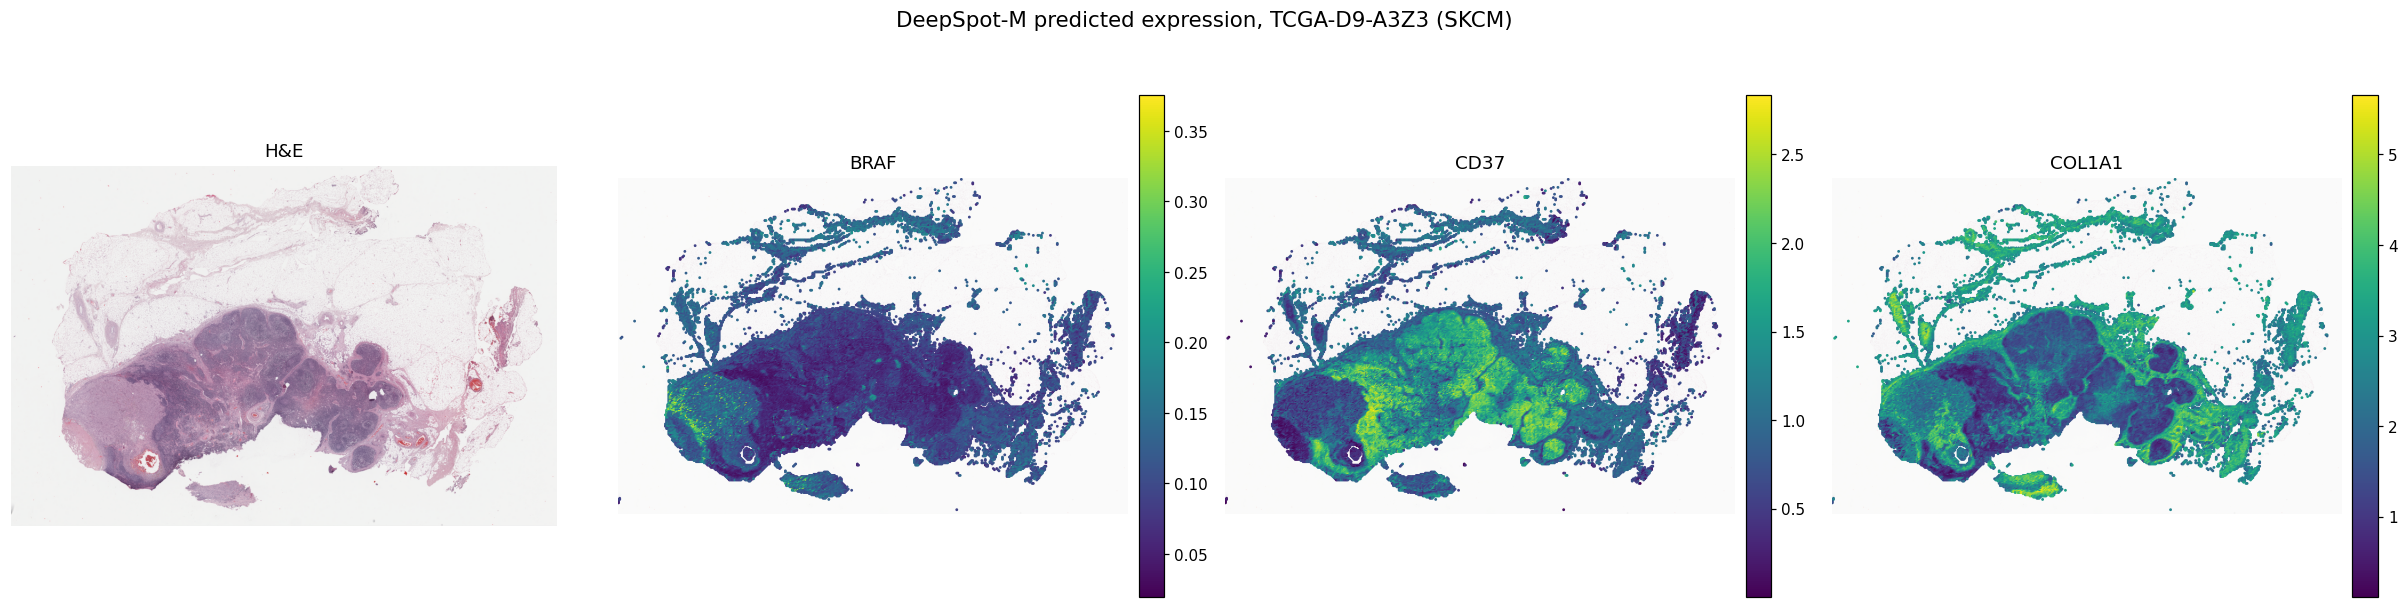

In [5]:
ov = pyvips.Image.thumbnail(SLIDE_PATH, 2000)
overview = np.ndarray(buffer=ov.write_to_memory(), dtype=np.uint8,
                      shape=[ov.height, ov.width, ov.bands])[..., :3]
oh, ow = overview.shape[:2]
sx, sy = ow / W, oh / H
cx = (coords[:, 0] + TILE / 2) * sx
cy = (coords[:, 1] + TILE / 2) * sy

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
axes[0].imshow(overview); axes[0].set_title("H&E"); axes[0].axis("off")
for i, gene in enumerate(GENES):
    ax = axes[i + 1]
    ax.imshow(overview, alpha=0.35)
    sc = ax.scatter(cx, cy, c=expr[:, i], s=0.7, cmap="viridis")
    ax.set_title(gene); ax.axis("off")
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.02)
fig.suptitle("DeepSpot-M predicted expression, TCGA-D9-A3Z3 (SKCM)", fontsize=14)
plt.tight_layout()
plt.show()